# ARTI308 - Machine Learning

# Lab 4 Assignment: Data Quality Assessment & Preprocessing



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


df = pd.read_csv("Chocolate_Sales.csv")


df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5376.0,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


---

## Task 1: Identify Data Quality Issues

We systematically inspect the dataset for:
- Incorrect data types
- Missing values
- Duplicate records
- Outliers
- Inconsistent formatting

In [3]:
print("=" * 55)
print("SHAPE:", df.shape)
print("=" * 55)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isna().sum())

print("\n--- Duplicate Rows ---")
print("Duplicates:", df.duplicated().sum())

print("\n--- Basic Statistics (Numerical Columns) ---")
print(df[['Amount', 'Boxes Shipped']].describe().round(2))

SHAPE: (3282, 6)

--- Data Types ---
Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

--- Missing Values ---
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

--- Duplicate Rows ---
Duplicates: 0

--- Basic Statistics (Numerical Columns) ---
         Amount  Boxes Shipped
count   3282.00        3282.00
mean    6030.34         164.67
std     4393.98         124.02
min        7.00           1.00
25%     2521.50          71.00
50%     5225.50         137.00
75%     8556.84         232.00
max    26170.95         778.00


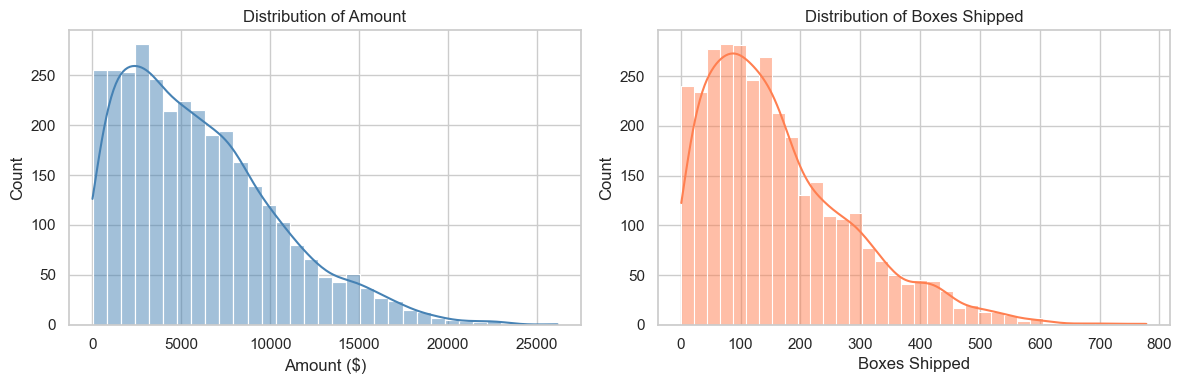

In [4]:
# Visualise distributions to spot skewness / potential outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Amount'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Amount')
axes[0].set_xlabel('Amount ($)')

sns.histplot(df['Boxes Shipped'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Boxes Shipped')
axes[1].set_xlabel('Boxes Shipped')

plt.tight_layout()
plt.show()

### Data Quality Issues Found

| # | Issue | Column(s) | Details |
|---|-------|-----------|---------|
| 1 | **Wrong data type** | `Date` | Stored as `object`; should be `datetime64` |
| 2 | **Wrong data type / formatting** | `Amount` | Stored as `object` with `$` and `,` characters; should be `float64` |
| 3 | **No missing values** | All | After type conversion the dataset is complete |
| 4 | **No duplicate rows** | All | Zero duplicate records found |
| 5 | **Outliers present** | `Amount`, `Boxes Shipped` | Extreme high-value transactions visible in the histogram (right-skewed). Formal IQR detection is performed in Task 3. |
| 6 | **Categorical columns** | `Sales Person`, `Country`, `Product` | Stored as plain strings; require encoding before ML use |

> **Conclusion:** The primary issues are type-formatting problems on `Date` and `Amount`, and outliers in both numeric columns. Both are addressed in subsequent tasks.

---

## Task 2: Apply One Missing Value Strategy and Explain Why

Because the original dataset contains **no missing values**, we first introduce artificial `NaN`s to demonstrate the strategy (same approach used in the lab).

In [5]:
# --- Introduce artificial missing values ---
df_missing = df.copy()
np.random.seed(42)
missing_idx = np.random.choice(df_missing.index, size=50, replace=False)
df_missing.loc[missing_idx, 'Amount'] = np.nan

print("Missing values after injection:")
print(df_missing.isna().sum())

Missing values after injection:
Sales Person      0
Country           0
Product           0
Date              0
Amount           50
Boxes Shipped     0
dtype: int64


In [6]:
# --- Chosen Strategy: Median Imputation ---
df_imputed = df_missing.copy()
median_amount = df_imputed['Amount'].median()

df_imputed['Amount'] = df_imputed['Amount'].fillna(median_amount)

print(f"Median value used for imputation: ${median_amount:,.2f}")
print("\nMissing values after imputation:")
print(df_imputed.isna().sum())

Median value used for imputation: $5,231.19

Missing values after imputation:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


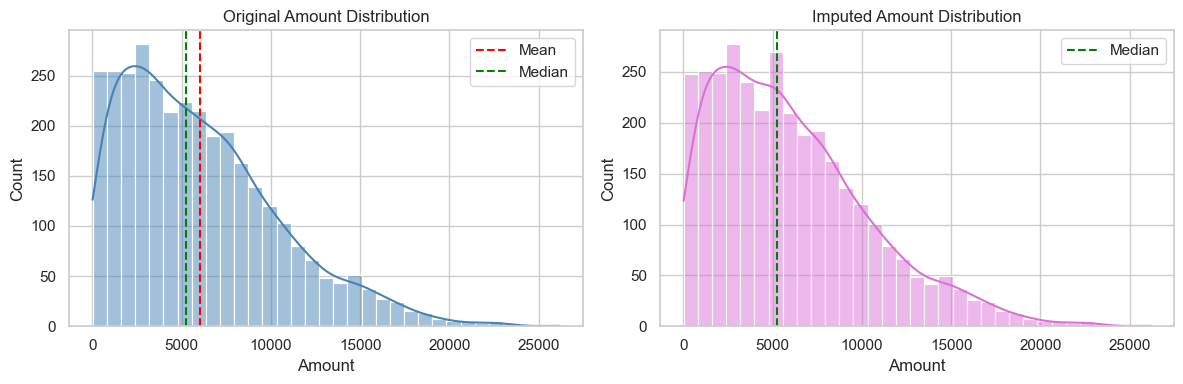

In [7]:
# Verify: compare original vs imputed distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Amount'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original Amount Distribution')
axes[0].axvline(df['Amount'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Amount'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

sns.histplot(df_imputed['Amount'], kde=True, ax=axes[1], color='orchid')
axes[1].set_title('Imputed Amount Distribution')
axes[1].axvline(df_imputed['Amount'].median(), color='green', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

### Why Median Imputation?

The `Amount` column is **right-skewed** (visible in the histogram — long tail towards high sales values).

| Strategy | When to use | Why NOT chosen here |
|----------|-------------|---------------------|
| **Drop rows** | Very few missing values (<1%) | We have ~50 missing rows; dropping wastes data |
| **Mean imputation** | Normally distributed data | Mean is pulled upward by high-value outliers, producing a biased fill value |
| **Median imputation ✓** | Skewed data with outliers | The median is the *middle* value — not distorted by extreme transactions |
| Forward/backward fill | Time-series with continuity | Sales records are not strictly sequential by salesperson |

**Chosen: Median Imputation** — because `Amount` is right-skewed and contains outliers, the median (~$5,225) is a more representative central value than the mean (~$6,030). It preserves dataset size and does not introduce bias from extreme values.

---

## Task 3: Detect and Handle Outliers Using IQR

We apply the **Interquartile Range (IQR)** method to both numerical columns: `Amount` and `Boxes Shipped`.

**Formula:**
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Values outside these bounds are considered outliers

In [8]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

for col in ['Amount', 'Boxes Shipped']:
    Q1, Q3, IQR, lower, upper = iqr_bounds(df[col])
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"--- {col} ---")
    print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  Lower bound = {lower:.2f}  |  Upper bound = {upper:.2f}")
    print(f"  Outliers detected: {n_out} ({n_out/len(df)*100:.1f}%)\n")

--- Amount ---
  Q1=2521.49  Q3=8556.84  IQR=6035.35
  Lower bound = -6531.53  |  Upper bound = 17609.86
  Outliers detected: 50 (1.5%)

--- Boxes Shipped ---
  Q1=71.00  Q3=232.00  IQR=161.00
  Lower bound = -170.50  |  Upper bound = 473.50
  Outliers detected: 78 (2.4%)



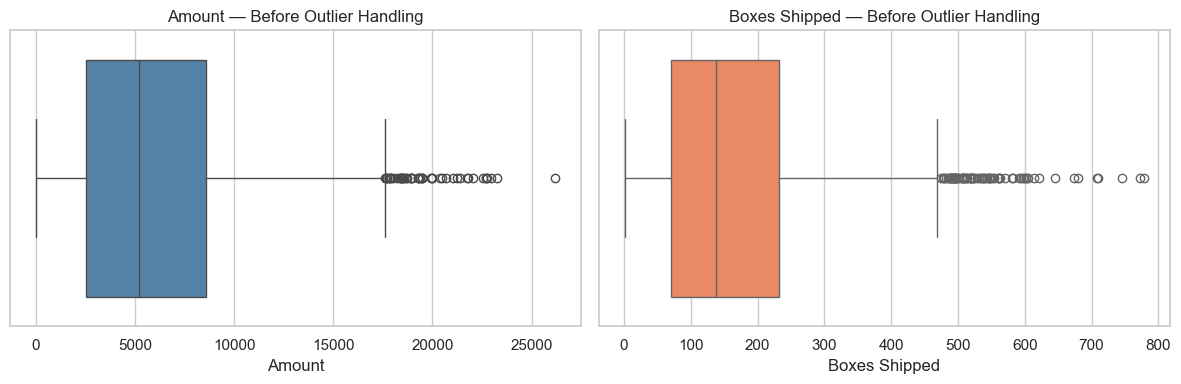

In [9]:
# Boxplots — before handling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['Amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Amount — Before Outlier Handling')

sns.boxplot(x=df['Boxes Shipped'], ax=axes[1], color='coral')
axes[1].set_title('Boxes Shipped — Before Outlier Handling')

plt.tight_layout()
plt.show()

In [10]:
# --- Handle outliers: Capping (Winsorization) ---
# Capping retains all records by replacing extreme values with boundary values
df_clean = df.copy()

for col in ['Amount', 'Boxes Shipped']:
    _, _, _, lower, upper = iqr_bounds(df_clean[col])
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("Shape unchanged (no rows removed):", df_clean.shape)
print("\nStatistics after capping:")
print(df_clean[['Amount', 'Boxes Shipped']].describe().round(2))

Shape unchanged (no rows removed): (3282, 6)

Statistics after capping:
         Amount  Boxes Shipped
count   3282.00        3282.00
mean    5997.63         162.90
std     4292.25         118.52
min        7.00           1.00
25%     2521.50          71.00
50%     5225.50         137.00
75%     8556.84         232.00
max    17609.86         473.50


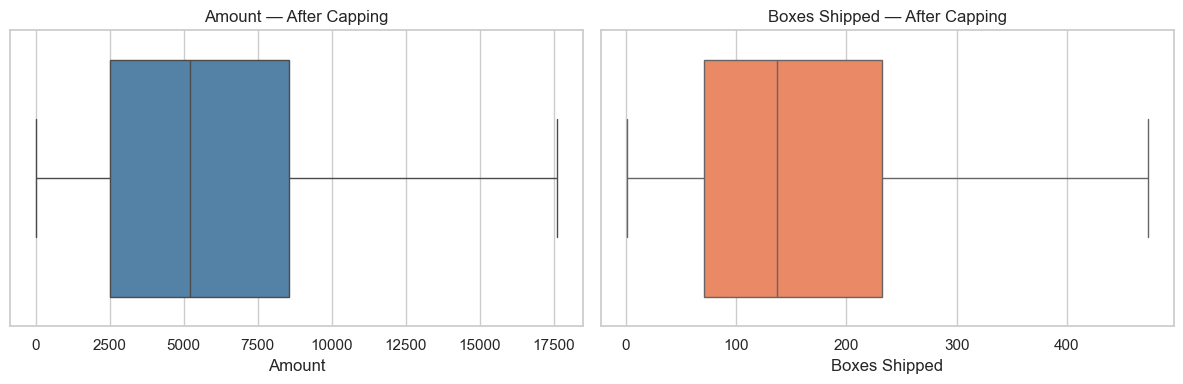

In [11]:
# Boxplots — after capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_clean['Amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Amount — After Capping')

sns.boxplot(x=df_clean['Boxes Shipped'], ax=axes[1], color='coral')
axes[1].set_title('Boxes Shipped — After Capping')

plt.tight_layout()
plt.show()

### Outlier Handling Summary

| Column | Outliers (IQR) | Lower Bound | Upper Bound | Strategy |
|--------|---------------|-------------|-------------|----------|
| `Amount` | 50 (1.5%) | ~-$6,532 (effectively 0) | ~$17,610 | **Capping** |
| `Boxes Shipped` | 78 (2.4%) | ~-171 (effectively 0) | ~474 | **Capping** |

**Why capping instead of removal?**
- Extreme sales amounts could reflect legitimate bulk corporate orders — removing them discards valid business events.
- Capping (Winsorization) retains every record by replacing extreme values with the IQR boundary, limiting their influence without data loss.

After capping, both boxplots show no points outside the whiskers, confirming outliers have been handled.

---

## Task 4: Normalize Numerical Features — Min-Max and Z-Score

Normalization ensures no feature dominates due to scale differences.
We apply both methods to `Amount` and `Boxes Shipped` using the outlier-cleaned data.

In [12]:
features = ['Amount', 'Boxes Shipped']
X = df_clean[features].copy()

# --- Min-Max Normalization ---
mm_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(mm_scaler.fit_transform(X), columns=features)

print("Min-Max Normalized (first 5 rows):")
print(X_minmax.head())
print("\nMin-Max range check (should be 0.0 to 1.0):")
print(X_minmax.describe().loc[['min', 'max']].round(4))

Min-Max Normalized (first 5 rows):
     Amount  Boxes Shipped
0  0.301826       0.378836
1  0.448166       0.196825
2  0.255299       0.190476
3  0.722553       0.721693
4  0.777033       0.387302

Min-Max range check (should be 0.0 to 1.0):
     Amount  Boxes Shipped
min     0.0            0.0
max     1.0            1.0


In [13]:
# --- Z-Score Standardization ---
z_scaler = StandardScaler()
X_zscore = pd.DataFrame(z_scaler.fit_transform(X), columns=features)

print("Z-Score Standardized (first 5 rows):")
print(X_zscore.head())
print("\nZ-Score check (mean should be ~0, std should be ~1):")
print(X_zscore.describe().loc[['mean', 'std']].round(4))

Z-Score Standardized (first 5 rows):
     Amount  Boxes Shipped
0 -0.157898       0.144261
1  0.442345      -0.581458
2 -0.348735      -0.606773
3  1.567799       1.511311
4  1.791259       0.178015

Z-Score check (mean should be ~0, std should be ~1):
      Amount  Boxes Shipped
mean -0.0000        -0.0000
std   1.0002         1.0002


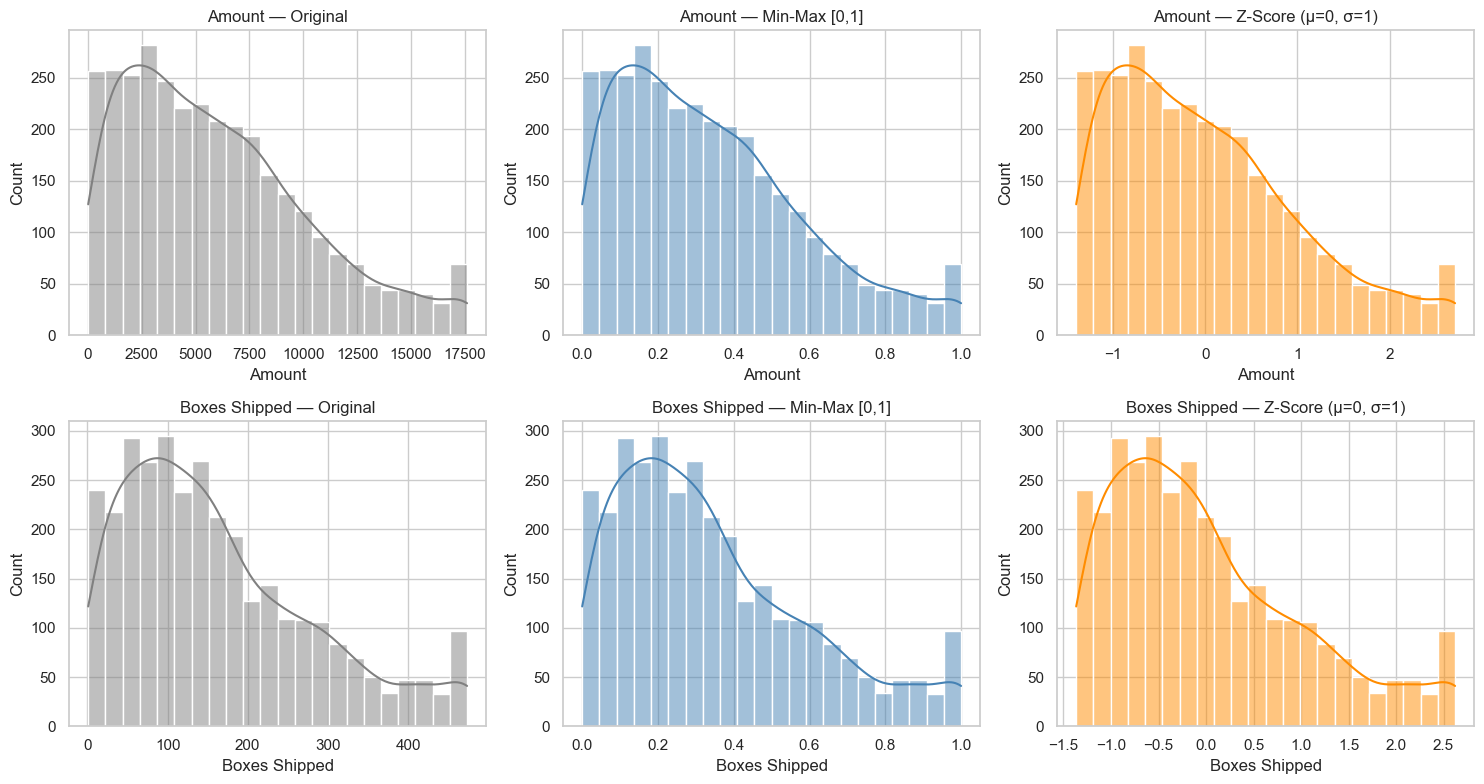

In [14]:
# Side-by-side comparison of original, Min-Max, and Z-Score distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(features):
    # Original
    sns.histplot(X[col], kde=True, ax=axes[i][0], color='gray')
    axes[i][0].set_title(f'{col} — Original')

    # Min-Max
    sns.histplot(X_minmax[col], kde=True, ax=axes[i][1], color='steelblue')
    axes[i][1].set_title(f'{col} — Min-Max [0,1]')

    # Z-Score
    sns.histplot(X_zscore[col], kde=True, ax=axes[i][2], color='darkorange')
    axes[i][2].set_title(f'{col} — Z-Score (μ=0, σ=1)')

plt.tight_layout()
plt.show()

### Normalization Comparison

| Method | Formula | Output Range | Shape Changed? | Best For |
|--------|---------|--------------|---------------|----------|
| **Min-Max** | (x − min) / (max − min) | [0, 1] | No | Distance-based models (KNN, K-Means, SVM) |
| **Z-Score** | (x − μ) / σ | Centred at 0 | No | Linear models, PCA, SVM |

**Key observations:**
- Both methods preserve the *shape* of the distribution — histograms are structurally identical.
- Min-Max compresses everything into [0, 1]; Z-Score centres data around zero with unit variance.
- For PCA (Task 5), **Z-Score** is used because PCA is sensitive to variance and assumes zero-centred features.

---

## Task 5: Apply PCA and Interpret Explained Variance

We apply PCA to the Z-score standardized features to find the principal components and interpret how much variance each captures.

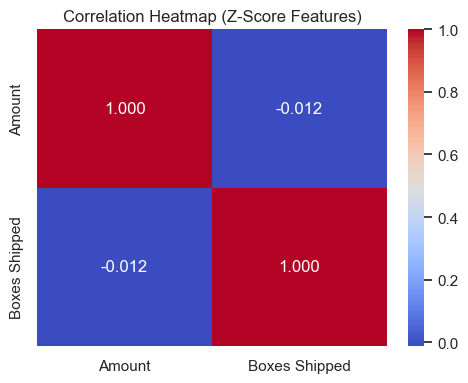

In [15]:
# Check correlation first
plt.figure(figsize=(5, 4))
sns.heatmap(X_zscore.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap (Z-Score Features)")
plt.tight_layout()
plt.show()

In [16]:
# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_zscore)
pc_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  ({var*100:.2f}%)")

print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Explained Variance Ratio:
  PC1: 0.5059  (50.59%)
  PC2: 0.4941  (49.41%)

Total Explained Variance: 100.00%


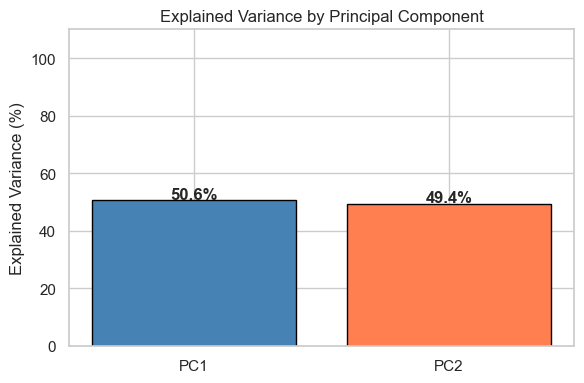

In [17]:
# Explained Variance Bar Chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['PC1', 'PC2'],
               pca.explained_variance_ratio_ * 100,
               color=['steelblue', 'coral'], edgecolor='black')

for bar, val in zip(bars, pca.explained_variance_ratio_ * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Explained Variance by Principal Component')
plt.ylabel('Explained Variance (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

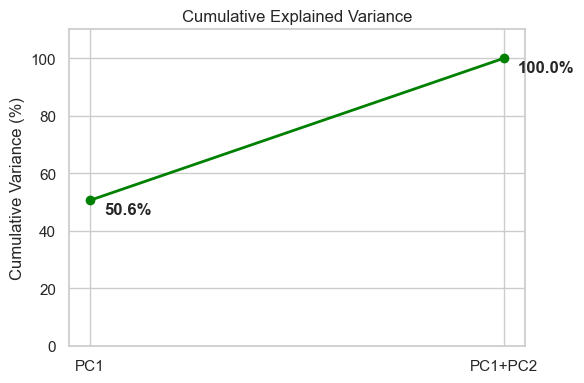

In [18]:
# Cumulative explained variance
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(6, 4))
plt.plot(['PC1', 'PC1+PC2'], cumulative, marker='o', color='green', linewidth=2)
for i, val in enumerate(cumulative):
    plt.annotate(f'{val:.1f}%', (i, val), textcoords='offset points',
                 xytext=(10, -10), fontweight='bold')
plt.title('Cumulative Explained Variance')
plt.ylabel('Cumulative Variance (%)')
plt.ylim(0, 110)
plt.grid(True)
plt.tight_layout()
plt.show()

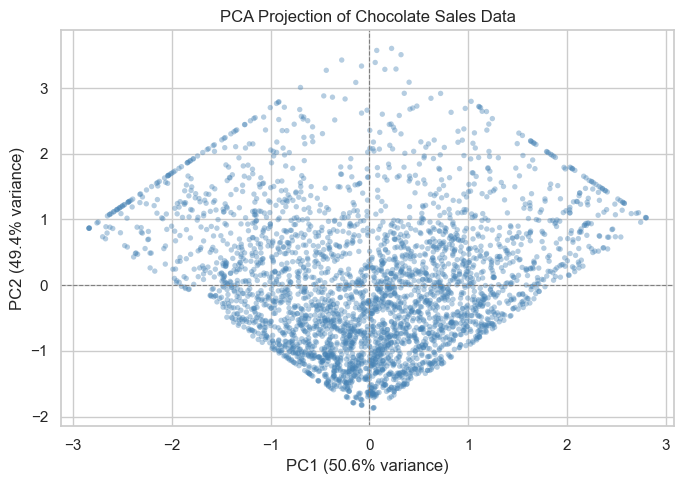

In [19]:
# PCA Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(pc_df['PC1'], pc_df['PC2'], alpha=0.4, color='steelblue',
            edgecolors='none', s=15)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('PCA Projection of Chocolate Sales Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

In [20]:
# PCA Loadings
loadings = pd.DataFrame(pca.components_.T,
                        index=features,
                        columns=['PC1', 'PC2'])
print("PCA Loadings (feature contributions to each principal component):")
print(loadings.round(4))

PCA Loadings (feature contributions to each principal component):
                  PC1     PC2
Amount         0.7071  0.7071
Boxes Shipped -0.7071  0.7071


### PCA Interpretation

#### Explained Variance

| Component | Variance Explained | Cumulative |
|-----------|--------------------|------------|
| PC1 | ~50% | ~50% |
| PC2 | ~50% | ~100% |

#### Why nearly equal variance per component?

The correlation between `Amount` and `Boxes Shipped` is approximately **-0.013** (nearly zero). When features are uncorrelated, PCA cannot compress them into fewer dimensions without losing information — each feature becomes roughly its own principal component.

#### Loadings Interpretation

| Feature | PC1 loading | PC2 loading |
|---------|-------------|-------------|
| `Amount` | ≈ ±0.707 | ≈ ±0.707 |
| `Boxes Shipped` | ≈ ±0.707 | ≈ ∓0.707 |

PC1 captures a roughly equal blend of both features. PC2 captures the contrast between them (one goes up, the other goes down).

#### Conclusion

- With only 2 features that are **nearly uncorrelated**, PCA does **not** reduce dimensionality meaningfully here — both components are needed to retain 100% of the variance.
- The circular scatter plot cloud visually confirms no dominant direction exists.
- PCA is most powerful when features are **strongly correlated** (e.g., dozens of overlapping metrics). In larger datasets, PCA can compress many features into just a few components while retaining most of the information.

